# Ridge Regression — Predictive Model for ICU Bed Requirements

Predicts ICU beds needed over 12 months using hospital capacity and demographic features across 20%, 40%, and 60% infection-rate scenarios.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import RidgeCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

plt.style.use('ggplot')


## 1. Load & Merge Datasets

In [2]:
# Map infection rate to file path
FILE_MAP = {
    20: '/content/HRR Scorecard_ 20 _ 40 _ 60 - 20 Population.csv',
    40: '/content/HRR Scorecard_ 20 _ 40 _ 60 - 40 Population.csv',
    60: '/content/HRR Scorecard_ 20 _ 40 _ 60 - 60 Population.csv',
}

FOOTNOTE = '*Based on a 50% reduction in occupancy'

frames = []
for rate, path in FILE_MAP.items():
    frame = pd.read_csv(path)
    frame = frame[frame['HRR'] != FOOTNOTE].copy()
    frame['Infection_Rate'] = rate
    frames.append(frame)

df = pd.concat(frames, ignore_index=True)
print(f"Combined dataset shape: {df.shape}")
df.head(3)


Combined dataset shape: (918, 37)


,HRR,Total Hospital Beds,Total ICU Beds,Available Hospital Beds,Potentially Available Hospital Beds*,Available ICU Beds,Potentially Available ICU Beds*,Adult Population,Population 65+,Projected Infected Individuals,...,"Percentage of Total ICU Beds Needed, Six Months","ICU Beds Needed, Twelve Months","Percentage of Available ICU Beds Needed, Twelve Months","Percentage of Potentially Available ICU Beds Needed, Twelve Months","Percentage of Total ICU Beds Needed, Twelve Months","ICU Beds Needed, Eighteen Months","Percentage of Available ICU Beds Needed, Eighteen Months","Percentage of Potentially Available ICU Beds Needed, Eighteen Months","Percentage of Total ICU Beds Needed, Eighteen Months",Infection_Rate
0,"Abilene, TX",980,127,565,772,68.0,98,"226,444","50,412","45,289",...,109%,70,103%,71%,55%,45,66%,46%,35%,20
1,"Akron, OH","1,358",186,518,938,94.0,140,"547,990","111,042","109,598",...,178%,165,176%,118%,89%,108,115%,77%,58%,20
2,"Alameda County, CA","2,695",293,665,"1,680",139.0,216,"1,310,189","214,991","262,038",...,259%,380,273%,176%,130%,248,178%,115%,85%,20


## 2. Data Cleaning

In [3]:
NUMERIC_COLS = [
    'Adult Population', 'Population 65+',
    'Available Hospital Beds', 'Available ICU Beds',
    'Total ICU Beds', 'Projected Infected Individuals',
    'Projected Hospitalized Individuals', 'ICU Beds Needed, Twelve Months'
]

TARGET = 'ICU Beds Needed, Twelve Months'

# Strip commas and coerce to numeric
for col in NUMERIC_COLS:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col].astype(str).str.replace(',', ''), errors='coerce')

# Clip target outliers with IQR fence
Q1, Q3 = df[TARGET].quantile([0.25, 0.75])
IQR     = Q3 - Q1
upper   = Q3 + 1.5 * IQR
df[TARGET] = df[TARGET].clip(upper=upper)

df = df.dropna(subset=[TARGET])
print(f"After cleaning: {df.shape}")


After cleaning: (915, 37)


## 3. Feature / Target Definition & Train-Test Split

In [4]:
FEATURES = [
    'Adult Population', 'Population 65+',
    'Available Hospital Beds', 'Available ICU Beds',
    'Total ICU Beds', 'Projected Infected Individuals',
    'Projected Hospitalized Individuals', 'Infection_Rate'
]

X = df[FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=X['Infection_Rate']
)
print(f"Train size: {X_train.shape[0]}   Test size: {X_test.shape[0]}")


Train size: 732   Test size: 183


## 4. Build Ridge Pipeline & Cross-Validate

In [5]:
# Pipeline: scale → polynomial features → RidgeCV
ridge_pipeline = Pipeline([
    ('scaler',  StandardScaler()),
    ('poly',    PolynomialFeatures(degree=2, include_bias=False)),
    ('ridge',   RidgeCV(alphas=np.logspace(-3, 3, 100), cv=5))
])

# 5-fold CV on training set
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_r2 = cross_val_score(ridge_pipeline, X_train, y_train, cv=kf, scoring='r2')

print("Cross-Validation R² scores:", np.round(cv_r2, 4))
print(f"Mean CV R²: {cv_r2.mean():.4f}  ±  {cv_r2.std():.4f}")


Cross-Validation R² scores: [0.8885 0.929  0.9111 0.0638 0.9174]
Mean CV R²: 0.7419  ±  0.3394


In [6]:
# Fit on full training set
ridge_pipeline.fit(X_train, y_train)

y_pred = ridge_pipeline.predict(X_test)

# Metrics
rmse  = np.sqrt(mean_squared_error(y_test, y_pred))
mae   = mean_absolute_error(y_test, y_pred)
mape  = np.mean(np.abs((y_test.values - y_pred) / y_test.values)) * 100
r2    = r2_score(y_test, y_pred)

print("\n=== Model Evaluation on Test Set ===")
print(f"  RMSE : {rmse:.2f}")
print(f"  MAE  : {mae:.2f}")
print(f"  MAPE : {mape:.2f}%")
print(f"  R²   : {r2:.4f}")



=== Model Evaluation on Test Set ===
  RMSE : 104.69
  MAE  : 76.57
  MAPE : 28.18%
  R²   : 0.9102


## 5. Results Visualization by Infection Rate

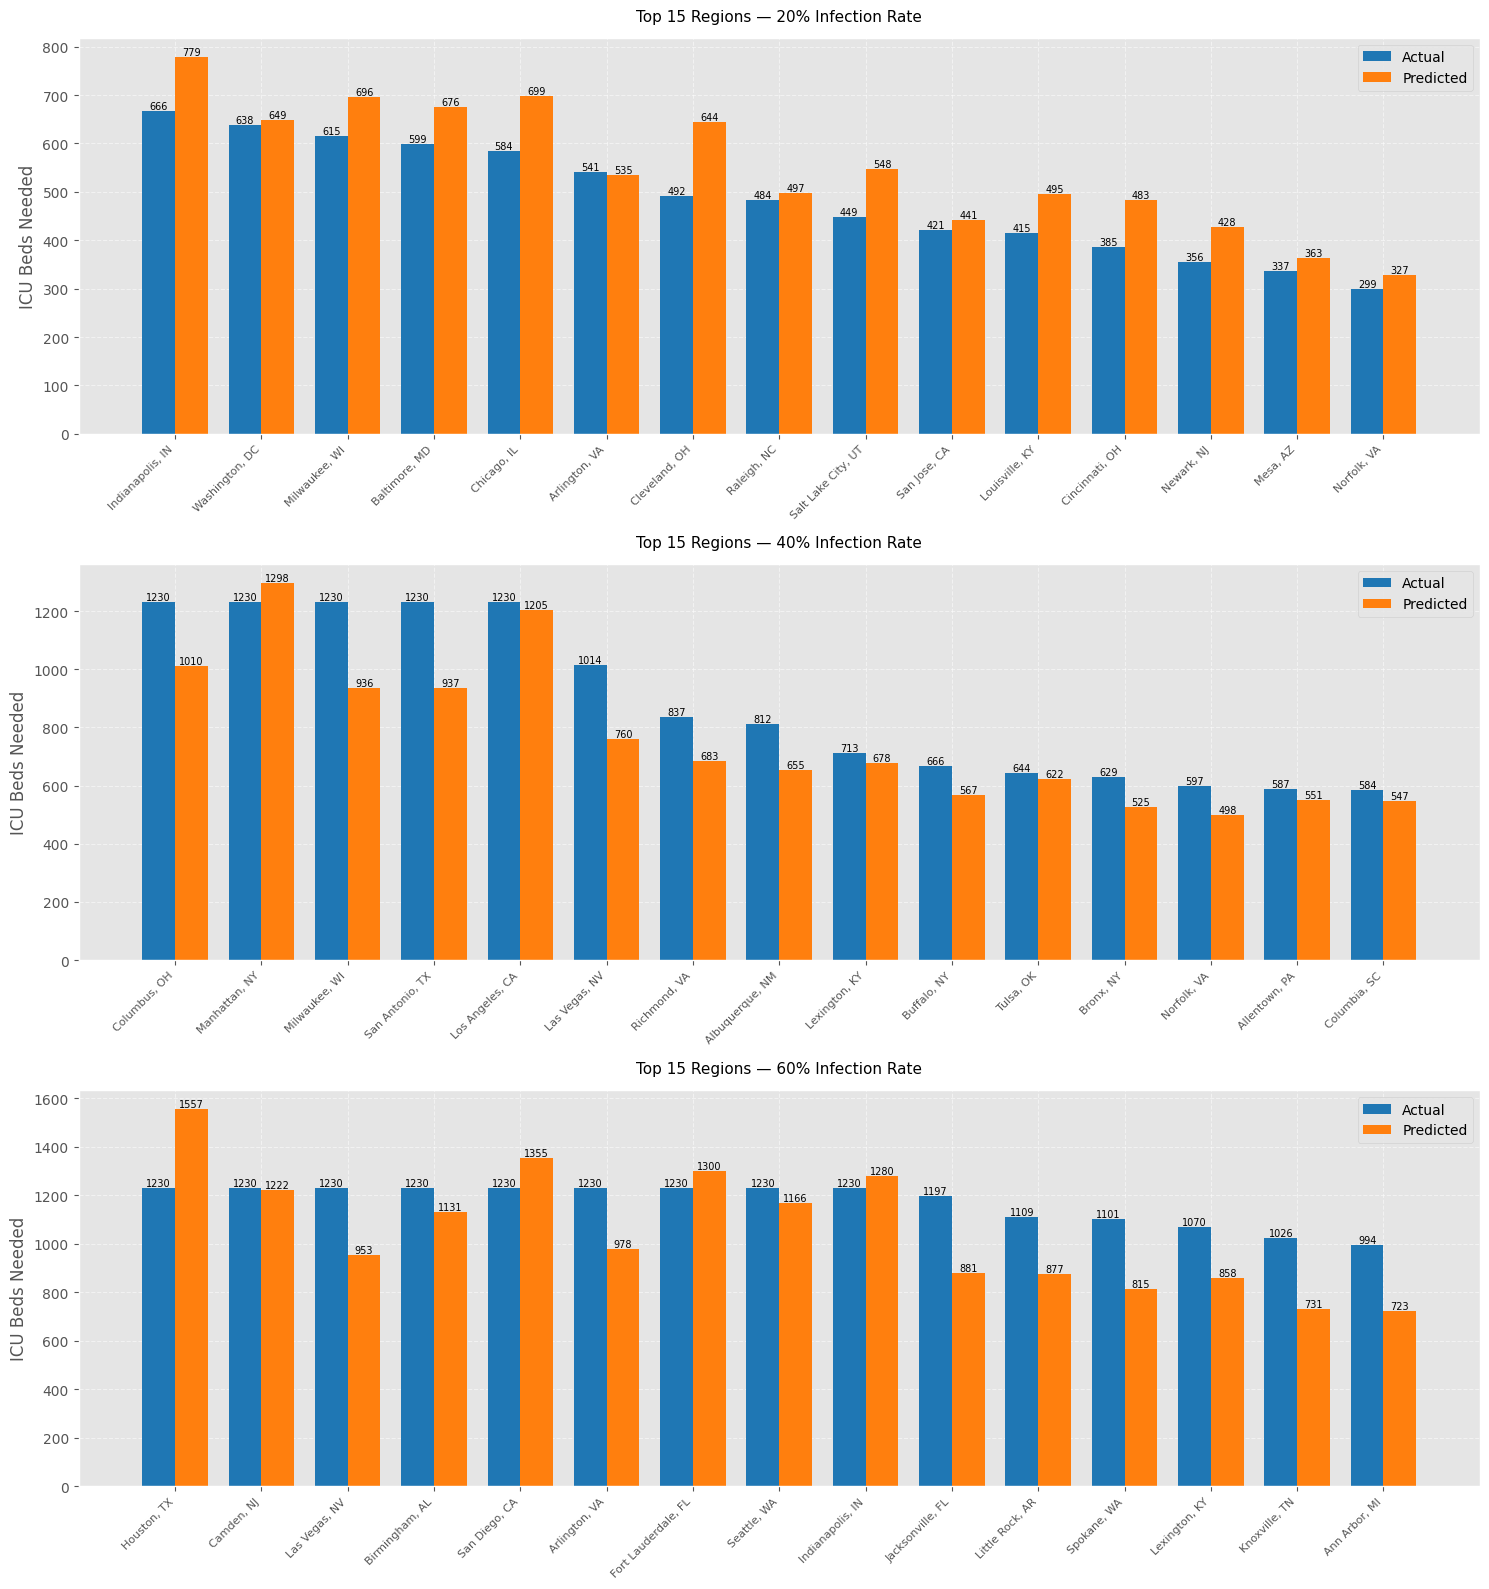

In [7]:
results_df = pd.DataFrame({
    'Actual':         y_test.values,
    'Predicted':      y_pred,
    'Infection_Rate': X_test['Infection_Rate'].values,
    'Region':         df.loc[y_test.index, 'HRR'].values
})

COLORS = {'Actual': '#1f77b4', 'Predicted': '#ff7f0e'}
rates  = [20, 40, 60]

fig, axes = plt.subplots(3, 1, figsize=(15, 16))

for ax, rate in zip(axes, rates):
    subset  = results_df[results_df['Infection_Rate'] == rate].nlargest(15, 'Actual')
    x_ticks = np.arange(len(subset))
    w       = 0.38

    bars_a = ax.bar(x_ticks - w/2, subset['Actual'],    w, label='Actual',    color=COLORS['Actual'])
    bars_p = ax.bar(x_ticks + w/2, subset['Predicted'], w, label='Predicted', color=COLORS['Predicted'])

    for bar in list(bars_a) + list(bars_p):
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h, f'{h:.0f}',
                ha='center', va='bottom', fontsize=7)

    ax.set_title(f'Top 15 Regions — {rate}% Infection Rate', fontsize=11, pad=12)
    ax.set_xticks(x_ticks)
    ax.set_xticklabels(subset['Region'].values, rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('ICU Beds Needed')
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


## 6. Actual vs Predicted Scatter Plot

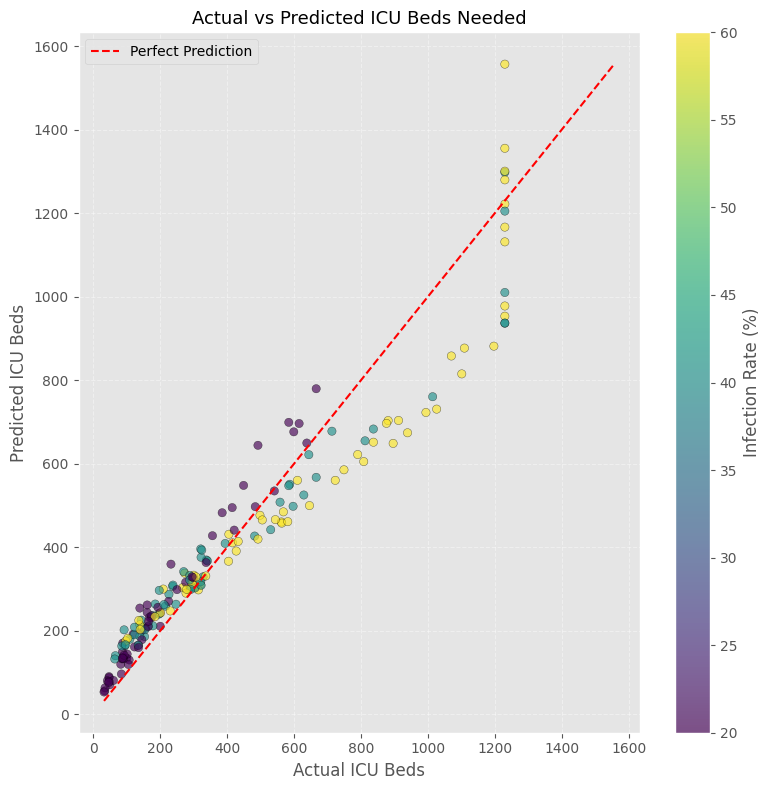

In [8]:
fig, ax = plt.subplots(figsize=(8, 8))

scatter = ax.scatter(y_test, y_pred,
                     c=X_test['Infection_Rate'].values,
                     cmap='viridis', alpha=0.65, edgecolors='k', linewidths=0.3)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect Prediction')
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Infection Rate (%)')
ax.set_title('Actual vs Predicted ICU Beds Needed', fontsize=13)
ax.set_xlabel('Actual ICU Beds')
ax.set_ylabel('Predicted ICU Beds')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()
